# Low-overhead error detection for generalized Clifford circuits

In a [previous tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/ghz-spacetime-codes), we introduced spacetime codes as a tool for performing [low-overhead error detection with spacetime codes](https://arxiv.org/abs/2504.15725) on quantum circuits, which mainly consist of Clifford gates. We also outlined an example to use this error detection method to efficiently prepare high-fidelity GHZ states on hardware. This was a particularly useful example, since we analytically know that any two-qubit Pauli operator $Z_i Z_j$ with support on qubits $i, j$ is a stabilizer of the GHZ state and therefore a valid check of the quantum circuit preparing this state. In this tutorial, we expand the use of the mentioned error detection technique to general Clifford circuits, for which finding immediate valid checks is not trivial.

If you haven't done so, we encourage you to read [this tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/ghz-spacetime-codes) first, before moving forward with the information below.

### Requirements

Note that this tutorial has an external dependency. Please make sure to clone and install the [Paulice repository](https://github.com/smartiel/paulice/) by running `pip install -e .` in your local environment. Before starting this tutorial, ensure that you also have the following installed:
- Qiskit SDK v2.0 or later, with [visualization](https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization) support
- Qiskit Runtime v0.40 or later (`pip install qiskit-ibm-runtime`)
- NumPy v2.3.2 (`pip install numpy`)
- Matplotlib v3.10.7 (`pip install matplotlib`)

### Setup

In [1]:
from paulice import PauliceStation, pick_checks, Metric, NoiseModel
from qiskit import QuantumCircuit

import numpy as np

### Creating a random Clifford circuit

We begin by defining a function to create a random Clifford circuit on a desired number of qubits, consisting of Hadamard, Controlled-Z, S and √X gates. In error detection terminology, this will define our payload circuit.

In [12]:
def create_random_circuit(num_qubits: int):
    circuit = QuantumCircuit(num_qubits)
    circuit.h(range(num_qubits))
    for d in range(num_qubits):
        for i in range(d % 2, num_qubits - 1, 2):
            circuit.cz(i, i + 1)
        for q in range(num_qubits):
            if np.random.randint(0, 2):
                circuit.sx(q)
            if np.random.randint(0, 2):
                circuit.s(q)
            if np.random.randint(0, 2):
                circuit.sx(q)
    return circuit

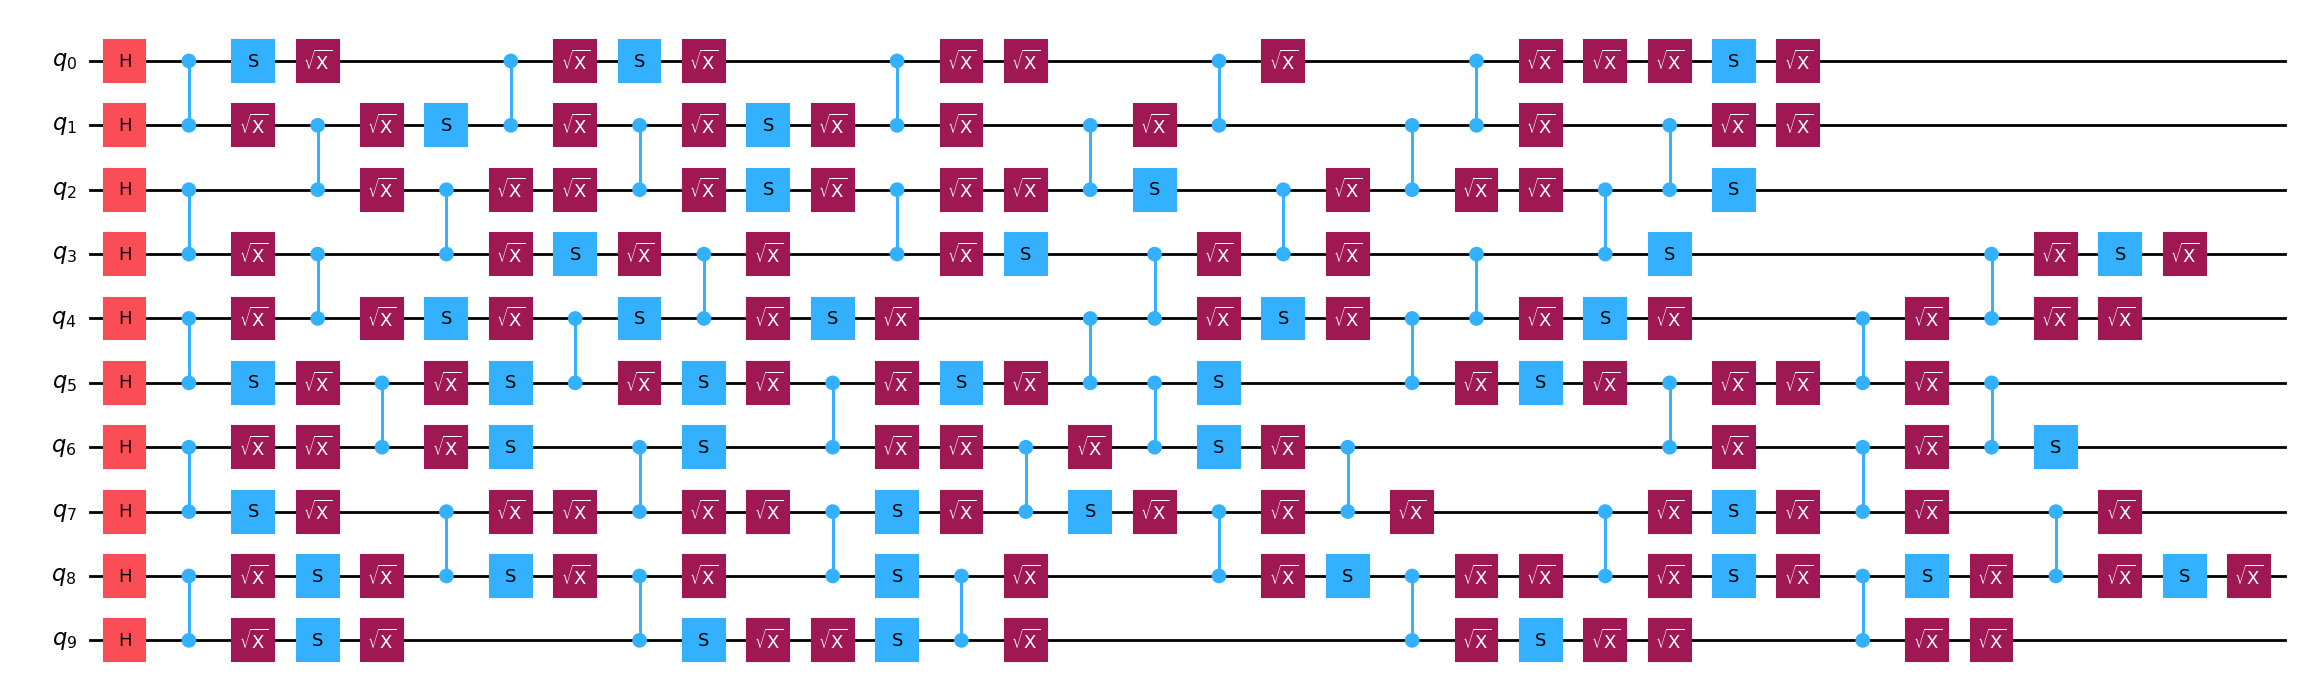

In [29]:
# Set a seed for reproducibility
np.random.seed(42) 

# Create the payload circuit
circuit = create_random_circuit(10)

# Display the payload circuit
circuit.draw("mpl", fold=-1)

### Noise model

Paulice models different sources of quantum noise to guide check placement.

In [30]:
# Noise models to include in the check picking
noise_models = [
    # Uniform depolarizing noise applied after each 2-qubit gate 
    # with probability 0.1%.
    # The corresponding error probability of each individual 
    # Pauli error (X, Y, or Z) is `probability / 3`.
    NoiseModel.uniform_depolarizing(1e-3),
    
    # Uniform readout noise applied before each measurement 
    # with probability 0.5%.
    # Adds single X error generators on each output qubit of the circuit, 
    # with the specified error rate.
    NoiseModel.readout(5e-3),
    
    # Idling noise on each idling qubit (in an ALAP scheduling).
    # Assumes that each H, SX gates have 50ns duration, 
    # and all CZ/CX gates have 60ns duration.
    # The parameter is the decay rate in ns.
    # The total error probability is given by `1 - exp(-t / decay_rate)`, 
    # where t is the wire's duration.
    NoiseModel.idling(1e5),
]

### Metrics

Metrics guide which Pauli checks are most useful for error detection.

In [31]:
# Target metric to guide check picking
metric = Metric.gamma()

### Picking checks

First, we implement a lower level interface to demonstrate how check picking works. The `PauliceStation` class gives us the ability to initiate the problem instance with the payload circuit, number of checks to add the noise model.


In [42]:
# Prepare the station to add 3 checks
station = PauliceStation(
    # The payload circuit to add checks to
    circuit=circuit,
    # Number of checks we would like to add
    n_checks_to_add=3,
    # Noise models
    noise_models=noise_models,
    # Target metric to guide the check picking
    metric=Metric.gamma(),
    # Qubits we want to measure at the end of the circuit
    measured_qubits="all",
    # Stabilizers present at the beginning of the circuit
    stabilizers=None,
)

In the workflow below, we try to find the best check that has the maximum amount of coverage of wires in the circuit. In other words, we are trying to figure out the check that can catch the maximum amount of errors in the payload circuit. `Paulice` casts this to an energy minimization problem, where the best check is the lowest energy solution.

In [43]:
print("Initial Ɣ:", station.get_current_energy())

# Add checks to qubits 2, 5, and 8, one by one
for target in [2, 5, 8]:
    # Wires, i.e. the spacetime locations where we can add checks
    wires = station.get_wires(target)
    # Set the wires as the support of the station, so that we only consider checks supported on these wires
    station.set_support(wires)
    # Computes the dimension of the underlying check group
    dim = station.get_dimension()
    # Pick 20 random checks
    all_checks = (np.random.randint(0, 2, (20, dim)) > 0.5).tolist()
    # Evaluate their energies (by default, using \gamma)
    all_checks_energies = [*map(station.evaluate, all_checks)]
    # Find the check with the lowest energy
    best_check = all_checks[np.argmin(all_checks_energies)]
    print("New Ɣ    :", all_checks_energies[np.argmin(all_checks_energies)])
    # Commit the best check:
    station = station.commit_check(best_check)

Initial Ɣ: 1.1281756760046113
New Ɣ    : 1.12757702134115
New Ɣ    : 1.147719728399683
New Ɣ    : 1.1148260179332539


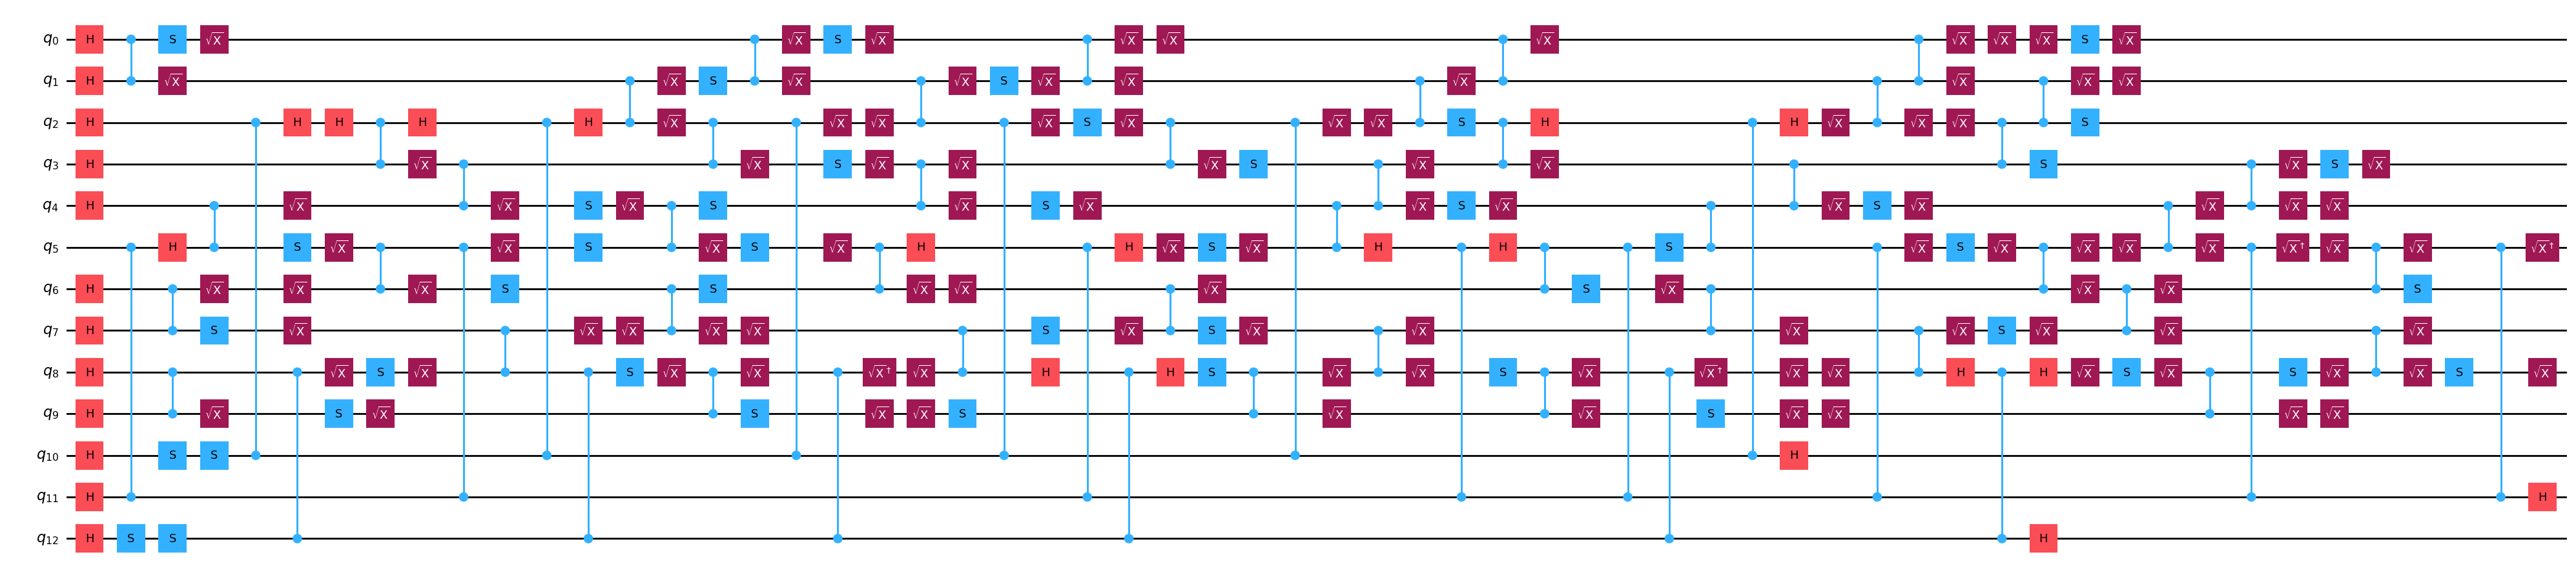

In [44]:
# Get the final circuit with added checks
final_circuit = station.get_circuit()
# Return the check qubit indices & their virtual CZ positions
check_qubits, virtual_czs = station.get_check_data()

# Display the circuit with checks
final_circuit.draw("mpl", fold=-1)

Now we can utilize a higher-level wrapper called `pick_checks`, which is implemented in `Paulice` library to guide check picking. This function takes in a payload circuit, some target data qubits to place checks on, a metric to optimize and a noise model. The output will be a circuit with the best checks that it can find. Note that there are 3 different search algorithms that can be selected to pick checks: ` "windowed" `, `"genetic"`, and `"windowed_genetic"` methods.

In [45]:
checked_circuit = pick_checks(
    # Payload circuit to add checks to
    circuit=circuit,
    # Target qubits to add checks on
    targets=[2, 5, 8],
    # Noise models to consider when picking checks
    noise_models=noise_models,
    # Metric to evaluate checks with
    metric=metric,
    # Measured qubits at the end of the circuit
    measured_qubits="all",
    # Optimization method to pick checks
    method="windowed",
    # Whether to print progress during check picking
    verbose=True,
    # Number of random checks to evaluate
    ntries=40,
)

[CHECK PICKING] Initial metric value: 1.1281756760046113
[WIN] Optimizing check 1/3 for target qubit 2
[WIN] Best check has score: 1.1102648892098184.
[WIN] Optimizing check 2/3 for target qubit 5
[WIN] Best check has score: 1.088304091354851.
[WIN] Optimizing check 3/3 for target qubit 8
[WIN] Best check has score: 1.0812166068151967.


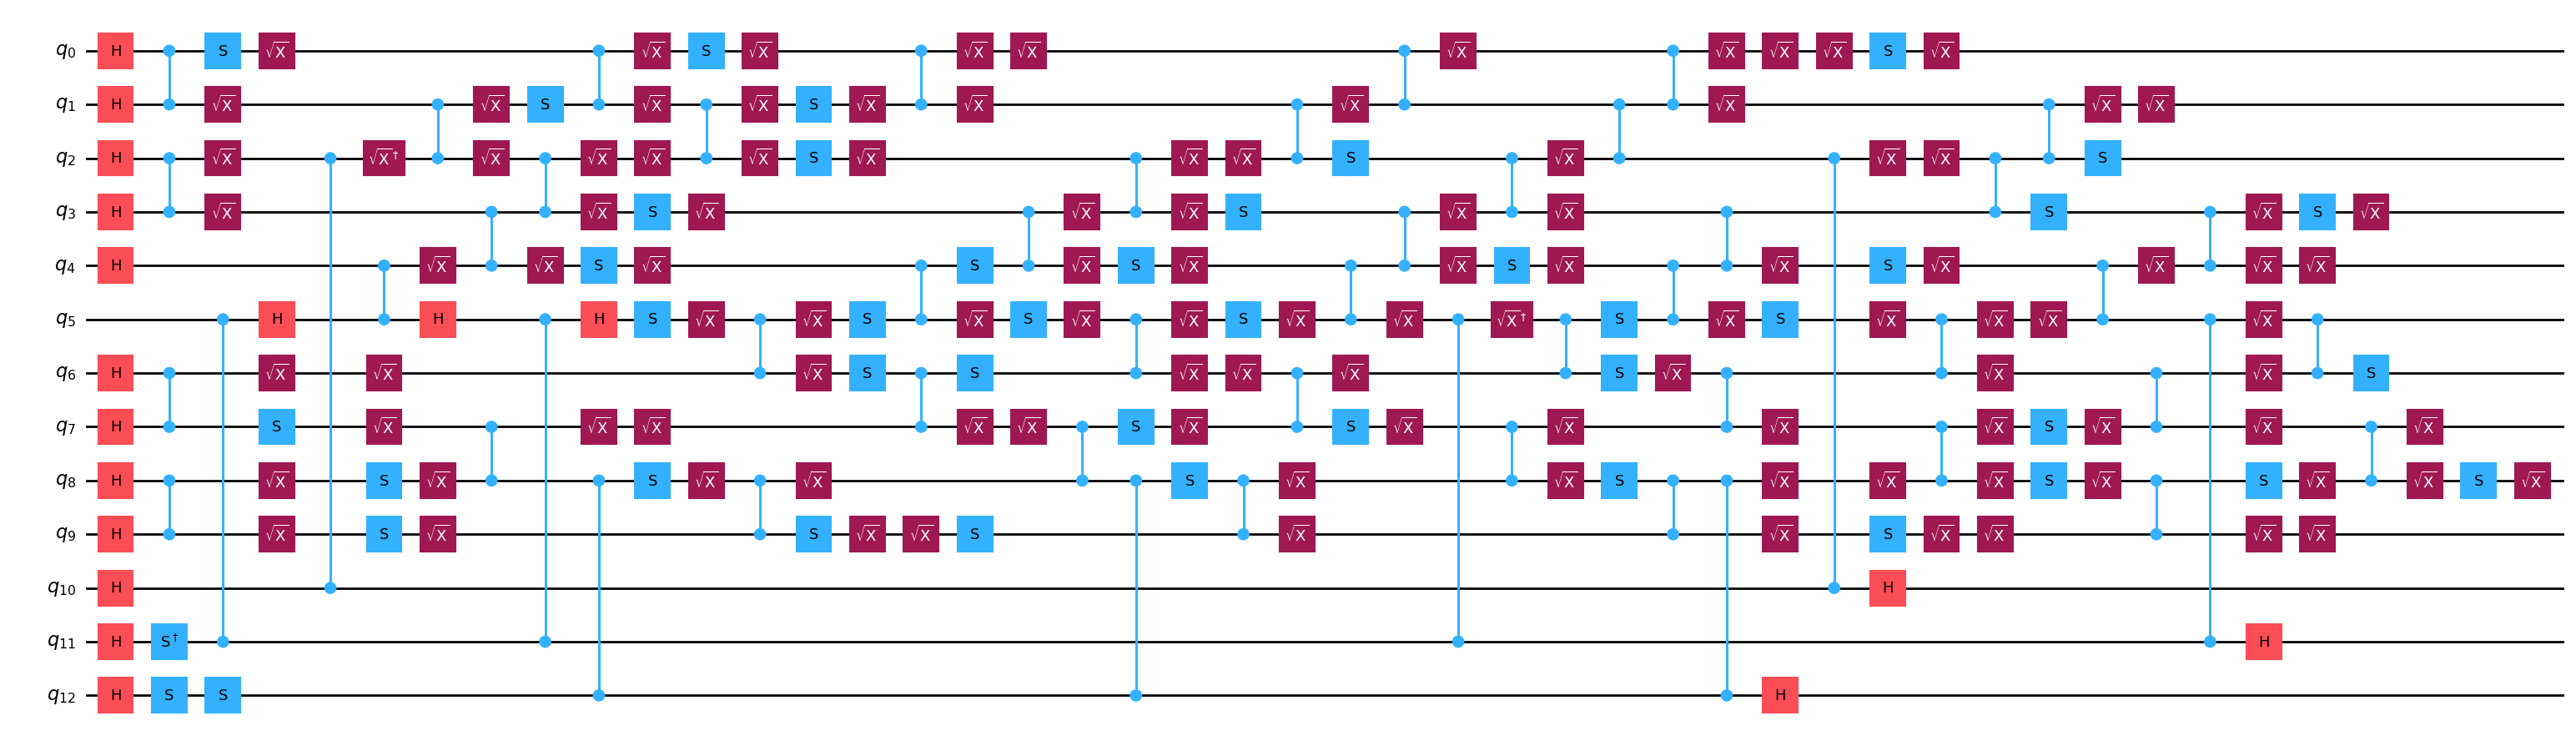

In [47]:
circuit_with_3_checks = checked_circuit.get_circuit(3)
circuit_with_3_checks.draw("mpl", fold=-1)